In [1]:
import matplotlib.pyplot as plt
import numpy as np
import joblib
import torch
from torch.utils.data import TensorDataset
from torch import nn

from net_utils import load_from_file
import plotting
import networks
import importlib
import os


In [16]:
for netFile, imgsFile, label in [
        ('publish/conv/HebbNet[50,16,1]_train=cur1_incr=plus1_w1init=randn_b1init=scalar_w2init=scalar.pkl',
                           'publish\conv\BradyOliva2008_UniqueObjects_ResNet18.pkl', 'featurize'),
]:

    folder, filename = os.path.split(netFile)
    idx = filename.find('[')
    if idx == -1:
        idx = filename.find('_')
    if idx == -1:
         raise ValueError('Invalid filename')  
    NetClass = getattr(importlib.import_module('networks'), filename[:idx])
    print(NetClass)   

    net = load_from_file(netFile)
    N,d = net.w1.shape
    print(net.hist['increment_R'][-1][1])
    x = torch.randn(10, d)
    check = net.featurizer(x).detach()



<class 'networks.HebbNet'>
17


AttributeError: 'HebbNet' object has no attribute 'featurizer'

### Plot generalization after training done

R=1, truePos=1.000, falsePos=0.000, acc=1.000=1.000, (chance=0.675)
R=2, truePos=1.000, falsePos=0.008, acc=0.990=0.995, (chance=0.640)
R=3, truePos=1.000, falsePos=0.015, acc=0.995=0.990, (chance=0.670)
R=4, truePos=1.000, falsePos=0.008, acc=0.995=0.995, (chance=0.660)
R=6, truePos=1.000, falsePos=0.023, acc=0.985=0.985, (chance=0.640)
R=8, truePos=0.985, falsePos=0.000, acc=0.995=0.995, (chance=0.665)
R=11, truePos=0.863, falsePos=0.000, acc=0.945=0.955, (chance=0.668)
R=15, truePos=0.571, falsePos=0.019, acc=0.860=0.857, (chance=0.697)
R=20, truePos=0.260, falsePos=0.022, acc=0.745=0.743, (chance=0.672)
R=26, truePos=0.160, falsePos=0.020, acc=0.723=0.723, (chance=0.687)
R=34, truePos=0.067, falsePos=0.024, acc=0.679=0.678, (chance=0.672)
R=45, truePos=0.031, falsePos=0.023, acc=0.674=0.674, (chance=0.680)
R=59, truePos=0.035, falsePos=0.022, acc=0.680=0.678, (chance=0.682)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


R=77, truePos=0.025, falsePos=0.031, acc=0.647=0.646, (chance=0.658)


array([<AxesSubplot:ylabel='Accuracy'>,
       <AxesSubplot:xlabel='$R_{test}$', ylabel='Probability'>],
      dtype=object)

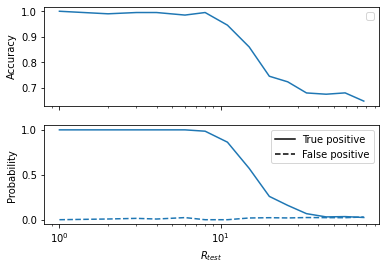

In [7]:
from networks import HebbFeatureLayer
from data import GenRecogClassifyData
from plotting import plot_generalization, get_recog_positive_rates

d = 50
Nh = 16
Ny = 1
Nx = 512

Tmul = 20
Tmin = 200
P = 0.5 # Probability of repeat
noMultiRep = True

net = HebbFeatureLayer(init=[d, Nh, Ny], Nx=Nx)
pretrained_weights = "results/tensor_board_logs_no_freeze/results/HebbFeature_no_freeze_(6).pkl"
net.load(pretrained_weights)
img_dataset = "publish/conv/BradyOliva2008_UniqueObjects_ResNet18.pkl"
images = torch.load(img_dataset)
dummyClasses = torch.zeros(images.shape[0],1)
sampleSpace = TensorDataset(images, dummyClasses)
generator = GenRecogClassifyData(sampleSpace=sampleSpace)
    
def generate_recog_data_batch(T,d,R,P,multiRep,batchSize,**kwargs):
    x,y = generator(T, R, P, batchSize, multiRep).tensors
    return TensorDataset(x, y[..., 0:1])

if type(net) == HebbFeatureLayer:
    assert images.shape[1] == Nx # sanity check

gen_data = lambda R: generate_recog_data_batch(T=max(Tmin, R*Tmul), 
                                                   d=d, 
                                                   R=R, 
                                                   P=P, 
                                                   softLabels=False,
                                                   interleave=True, 
                                                   multiRep=(not noMultiRep), 
                                                   batchSize=None,
                                                   xDataVals='+-',
                                                   device='cpu')

testR, testAcc, truePosRate, falsePosRate = get_recog_positive_rates(net, gen_data)
plot_generalization(testR, testAcc, truePosRate, falsePosRate)